# Introducão

Neste documento vamos apresentar de maneira consolidada o comportamento do modelo Before.IT, que foi detalhado na parte dois.  

Estas são as principais características do modelo: 

- Procura reproduzir e prever ("forecasting") os principais indicadores agregados da econônomia.
- Implementa o modelo de acordo com as premissas da contabilidade nacional, ou seja, reproduz as mesmas entidades, impostos, relações mapeados nas estatísticas econômicas da União Europeia, calibrando essas entidades para dar a maior similitude possível ao modelo. 
- Utiliza uma regra auto regressiva de ordem 1 ( AR(1) ) como forma de aprenzidado e previsão compartilhada dos agentes para os indicadores macroeconomicos, como crescimento da econômia (PIB) e inflação.
- Incorpora choques gaussianos aleatórios nas regras de expectativas AR(1). 
- Utiliza as expectativas macroeconomicas como premissa para construir as expectativas individuais dos agentes.
- Implementa mercados com frição e aleatoriedade onde, em geral, as expectativas são "quebradas" e as variáveis de expectativas se tornam variáveis realizadas.

Abaixo iremos explorar cada uma dessas características com exemplos práticos a partir do código. 


## Forecasting econômico 

Como descrito em `PaperOriginal`, a simulação procura prever o comportamento de agregados macroeconômicos nos próximos anos após o $t_0$ do modelo. Além disso, o modelo é comparado com outras metodologias de previsão econômica, como os modelos `DSGE e VARX (detalhar benchmarks)`.

Abaixo vamos rodar a simulação localmente e demonstrar essas variáveis ao longo do tempo. 

In [2]:
import BeforeIT as Bit # importando o modelo
using DataFrames
using Plots
using StatsBase
using Random

Random.seed!(123)

model = Bit.Model(
    Bit.AUSTRIA2010Q1.parameters,  # parametros das regras necessárias para rodar o modelo
    Bit.AUSTRIA2010Q1.initial_conditions, # condições iniciais analisadas abaixo
);

Simulation finished, step: 20


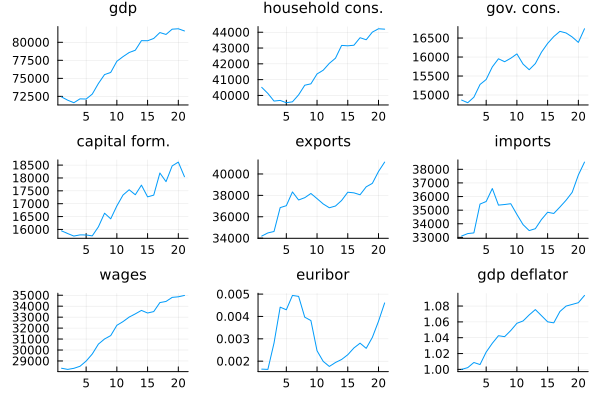

In [3]:
T = 20
for t in 1:T
    if t == T
        println("Simulation finished, step: ", t)
    end
    Bit.step!(model; parallel = true)
    Bit.collect_data!(model)
end

data = model.data

p1 = plot(data.real_gdp, title = "gdp", titlefont = 10)
p2 = plot(data.real_household_consumption, title = "household cons.", titlefont = 10)
p3 = plot(data.real_government_consumption, title = "gov. cons.", titlefont = 10)
p4 = plot(data.real_capitalformation, title = "capital form.", titlefont = 10)
p5 = plot(data.real_exports, title = "exports", titlefont = 10)
p6 = plot(data.real_imports, title = "imports", titlefont = 10)
p7 = plot(data.wages, title = "wages", titlefont = 10)
p8 = plot(data.euribor, title = "euribor", titlefont = 10)
p9 = plot(data.nominal_gdp ./ data.real_gdp, title = "gdp deflator", titlefont = 10)

plot(p1, p2, p3, p4, p5, p6, p7, p8, p9, layout = (3, 3), legend = false)

## Calibração e verossimilhança 

O modelo original conta com um total de `P` parâmetros que foram calibrados inicialmente para a economia da Austria e que depois foram adaptados para a economia da Itália em `Before.IT`.

`Escolher alguns parâmetros para ilustrar e depois exibir todos os parametros`

## Regra autoregressiva de ordem 1

O modelo utiliza uma regra autoregressiva de ordem 1 para que os agentes formem expectativas sobre duas variáveis: 
- Expectativa de PIB. 
- Expectativa de inflação. 

`detalhar regra AR(1)`

### Como funciona a regra AR(1)?

Para uma série $z_1,\ldots,z_n$, o modelo estima a regressão autorregressiva:

$$
z_t = \alpha z_{t-1} + \beta + u_t
$$

A estimação usa os pares:

$$
(z_1,z_2),\;(z_2,z_3),\ldots,(z_{n-1},z_n)
$$

que podem ser escritos como:

$$
\mathbf{y} =
\begin{bmatrix}
z_2\\
z_3\\
\vdots\\
z_n
\end{bmatrix},
\qquad
\mathbf{X} =
\begin{bmatrix}
z_1 & 1\\
z_2 & 1\\
\vdots & \vdots\\
z_{n-1} & 1
\end{bmatrix}
$$

Os valores de $\alpha$ e $\beta$ são escolhidos para minimizar a soma dos erros quadráticos:

$$
(\hat{\alpha},\hat{\beta})
=
\underset{\alpha,\beta}{\operatorname{argmin}}
\sum_{t=2}^{n}
\left(z_t-\alpha z_{t-1}-\beta\right)^2
$$

Em forma matricial:

$$
\begin{bmatrix}
\hat{\alpha}\\
\hat{\beta}
\end{bmatrix}
=
\mathbf{X}^{+}\mathbf{y}
$$

onde $\mathbf{X}^{+}$ é a pseudoinversa de $\mathbf{X}$, calculada no modelo por decomposição em valores singulares, ou SVD.

A interpretação dos parâmetros é:

- $\hat{\alpha}$ mede a persistência da série;
- $\hat{\beta}$ é o intercepto médio;
- $u_t$ representa a parte que a regressão não conseguiu explicar.

Após a estimação, calcula-se a variância dos resíduos:

$$
\hat{\sigma}_u^2 = \operatorname{Var}(\hat{u}_t)
$$

e sorteia-se um novo choque:

$$
\varepsilon_t \sim \mathcal{N}(0,\hat{\sigma}_u^2)
$$

A previsão seguinte é então:

$$
z_{n+1}^{e}
=
\hat{\alpha}z_n+\hat{\beta}+\varepsilon_t
$$



α real:     0.7000
α estimado: 0.6898
β real:     2.0000
β estimado: 1.9790


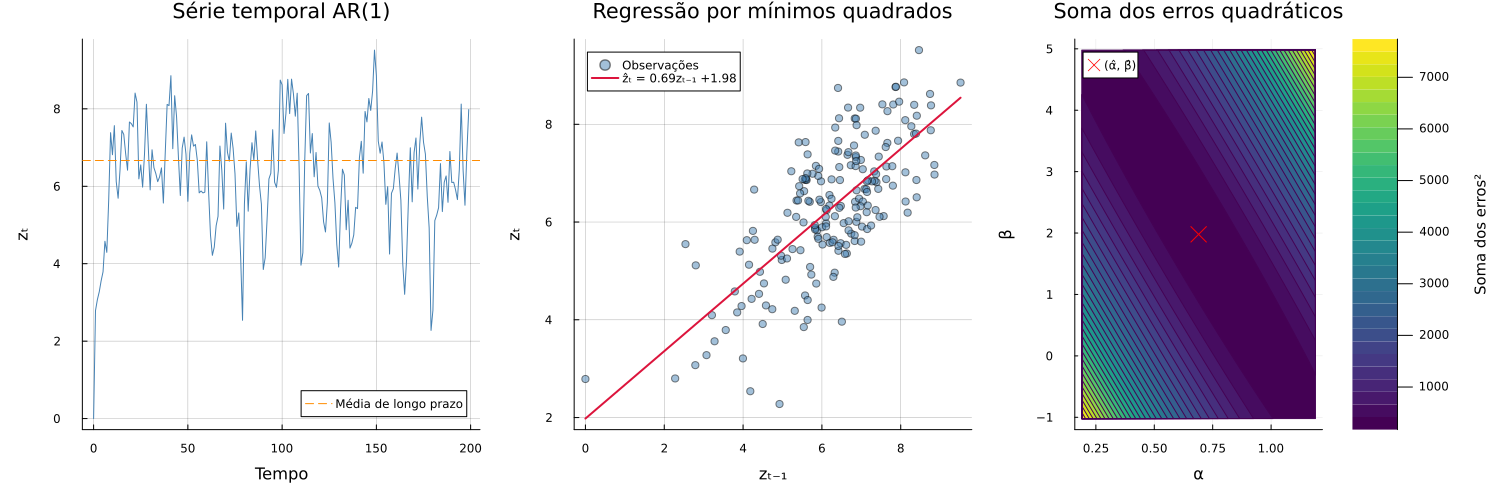

In [1]:
using Random
using Printf
using Plots

Random.seed!(42)

# Parâmetros
α_real = 0.7
β_real = 2.0
n = 200

# Geração da série AR(1)
z = zeros(n)

for t in 2:n
    erro = randn()
    z[t] = α_real * z[t-1] + β_real + erro
end

# y = zₜ e x = zₜ₋₁
x = z[1:end-1]
y = z[2:end]

# Mínimos quadrados
X = hcat(x, ones(length(x)))
α_estimado, β_estimado = X \ y
y_estimado = α_estimado .* x .+ β_estimado

@printf("α real:     %.4f\n", α_real)
@printf("α estimado: %.4f\n", α_estimado)
@printf("β real:     %.4f\n", β_real)
@printf("β estimado: %.4f\n", β_estimado)

# 1. Série temporal
p1 = plot(
    0:(n-1), z;
    color=:steelblue,
    title="Série temporal AR(1)",
    xlabel="Tempo",
    ylabel="zₜ",
    label=false,
    gridalpha=0.3,
)

hline!(
    p1,
    [β_real / (1 - α_real)];
    color=:darkorange,
    linestyle=:dash,
    label="Média de longo prazo",
)

# 2. Regressão
ordem = sortperm(x)

p2 = scatter(
    x, y;
    alpha=0.5,
    color=:steelblue,
    label="Observações",
    title="Regressão por mínimos quadrados",
    xlabel="zₜ₋₁",
    ylabel="zₜ",
    gridalpha=0.3,
)

plot!(
    p2,
    x[ordem],
    y_estimado[ordem];
    color=:crimson,
    linewidth=2,
    label=@sprintf(
        "ẑₜ = %.2fzₜ₋₁ %+.2f",
        α_estimado,
        β_estimado,
    ),
)

# 3. Soma dos erros quadráticos
valores_α = range(
    α_estimado - 0.5,
    α_estimado + 0.5;
    length=120,
)

valores_β = range(
    β_estimado - 3,
    β_estimado + 3;
    length=120,
)

soma_erros = [
    sum((y .- α .* x .- β) .^ 2)
    for β in valores_β, α in valores_α
]

p3 = contourf(
    valores_α,
    valores_β,
    soma_erros;
    levels=30,
    color=:viridis,
    title="Soma dos erros quadráticos",
    xlabel="α",
    ylabel="β",
    colorbar_title="Soma dos erros²",
)

scatter!(
    p3,
    [α_estimado],
    [β_estimado];
    color=:red,
    marker=:x,
    markersize=8,
    label="(α̂, β̂)",
)

@assert y_estimado ≈ X * [α_estimado, β_estimado]

plot(
    p1, p2, p3;
    layout=(1, 3),
    size=(1500, 500),
    left_margin=10Plots.mm,
    bottom_margin=10Plots.mm,
    top_margin=5Plots.mm,
)


#### Expectativas do PIB e da Inflação 

Primeiro, define-se o logaritmo do PIB:

$$
y_t = \log(Y_t)
$$

O valor esperado é estimado por um processo autorregressivo AR(1):

$$
y_t^e = \alpha_Y y_{t-1} + \beta_Y + \varepsilon_{Y,t}
$$

Convertendo novamente para o nível do PIB:

$$
Y_t^e = \exp(y_t^e)
$$

A taxa de crescimento esperada é:

$$
\gamma_t^e = \frac{Y_t^e}{Y_{t-1}} - 1
$$

Para a inflação, o modelo também estima um processo AR(1):

$$
q_t^e = \alpha_\pi q_{t-1} + \beta_\pi + \varepsilon_{\pi,t}
$$

$$
\pi_t^e = \exp(q_t^e) - 1
$$




`explicar como essas regras se traduzem em aprendizado`

#### Choques gaussianos 

`explicar choques gaussianos`

## Aplicação das expectativas

`dar o exemplo de como as empresas e famílias usam a expectativa para montar os orçamentos `

## Implementação dos mercados 

`detalhar mercados entre empresas e de consumo, e como isso "quebra" os planejamentos`